# Phase 2 (Obj B Short-Run): LP-IV Dynamics

This notebook focuses on short-run policy dynamics: LP-IV for inflation horizons (h=0..3) and GDP at h=0.

## Method summary

- Build exact horizon outcomes by matching country and calendar year.
- Estimate IV-TWFE per horizon with clustered standard errors by country.
- Report both coefficient significance and first-stage diagnostic strength.

In [1]:
from pathlib import Path
import warnings
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from linearmodels.iv import IV2SLS
from statsmodels.stats.multitest import multipletests
from statsmodels.tsa.filters.hp_filter import hpfilter

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")


def find_project_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / "02_data/analysis_ready/macro_growth_merged.csv").exists():
            return candidate
    raise FileNotFoundError("Could not find project root with analysis-ready data.")


ROOT = find_project_root(Path.cwd().resolve())
PANEL_PATH = ROOT / "02_data/analysis_ready/macro_growth_merged.csv"
CONTROLS_PATH = ROOT / "02_data/supporting/phase1_controls.csv"
INSTRUMENTS_PATH = ROOT / "02_data/supporting/phase1_instruments.csv"
IT_DATES_PATH = ROOT / "02_data/supporting/it_adoption_dates.csv"
OUT_DIR = ROOT / "03_analysis_notebooks/exports/phase2"
OUT_DIR.mkdir(parents=True, exist_ok=True)
RESTRICTED_CONTROLS = ["trade_open", "pop_growth", "investment_share"]
CHI2_1_95_CRITICAL = 3.841458820694124
STRONG_IV_STAT_THRESHOLD = 10.0
ROOT

PosixPath('/Users/stevenchung/Desktop/P12B_File/Monetary_Panel')

In [2]:
base = pd.read_csv(PANEL_PATH)
controls = pd.read_csv(CONTROLS_PATH)
instruments = pd.read_csv(INSTRUMENTS_PATH)
it_dates = pd.read_csv(IT_DATES_PATH)

panel = (
    base.merge(controls, on=["Country Name", "year"], how="left")
        .merge(instruments, on=["Country Name", "year"], how="left")
        .rename(columns={"Country Name": "country"})
        .sort_values(["country", "year"])
        .copy()
)

panel = panel.merge(
    it_dates[["country", "it_adoption_year_roger2010"]],
    on="country",
    how="left",
)
panel["it_group"] = np.where(panel["it_adoption_year_roger2010"].notna(), "adopter", "never_adopter")


def build_output_gap(df: pd.DataFrame) -> pd.Series:
    out = pd.Series(np.nan, index=df.index, dtype=float)
    for _, idx in df.groupby("country").groups.items():
        sub = df.loc[idx].sort_values("year")
        growth = sub["gdp_growth"].astype(float)
        if growth.notna().sum() < 10:
            continue
        level = np.log1p(growth.fillna(0.0)).cumsum()
        cycle, _ = hpfilter(level, lamb=6.25)
        out.loc[sub.index] = 100.0 * cycle
    return out


panel["output_gap_hp"] = build_output_gap(panel)
panel[["country", "year", "m2_growth", "inflation", "gdp_growth", "it_group", "output_gap_hp"]].head()

,country,year,m2_growth,inflation,gdp_growth,it_group,output_gap_hp
0,Afghanistan,2007,0.353436,0.083243,0.129504,never_adopter,0.462629
1,Afghanistan,2008,0.272953,0.234429,0.038499,never_adopter,-5.863908
2,Afghanistan,2009,0.285518,-0.070542,0.193843,never_adopter,1.675605
3,Afghanistan,2010,0.238600,0.021551,0.134203,never_adopter,4.880556
4,Afghanistan,2011,0.193172,0.111579,0.004254,never_adopter,-2.696633


In [3]:
def exact_horizon_series(source_df, target_df, value_col, horizon, entity_col="country", time_col="year", out_col=None):
    if horizon < 0:
        raise ValueError("horizon must be non-negative")

    out_col = out_col or f"{value_col}_h{horizon}"
    if horizon == 0:
        return target_df[value_col].copy()

    lookup = source_df[[entity_col, time_col, value_col]].dropna(subset=[value_col]).copy()
    lookup[time_col] = lookup[time_col] - horizon
    lookup = lookup.rename(columns={value_col: out_col}).drop_duplicates([entity_col, time_col], keep="last")
    aligned = target_df[[entity_col, time_col]].merge(lookup, on=[entity_col, time_col], how="left")
    return aligned[out_col]

horizons = {
    "inflation": [0, 1, 2, 3],
    "gdp_growth": [0],
}

lp_panel = panel.copy()
for outcome, hs in horizons.items():
    for h in hs:
        lp_panel[f"{outcome}_h{h}"] = exact_horizon_series(panel, lp_panel, outcome, h, out_col=f"{outcome}_h{h}")

lp_panel[["country", "year", "inflation_h0", "inflation_h1", "inflation_h2", "inflation_h3", "gdp_growth_h0"]].head()

,country,year,inflation_h0,inflation_h1,inflation_h2,inflation_h3,gdp_growth_h0
0,Afghanistan,2007,0.083243,0.234429,-0.070542,0.021551,0.129504
1,Afghanistan,2008,0.234429,-0.070542,0.021551,0.111579,0.038499
2,Afghanistan,2009,-0.070542,0.021551,0.111579,0.062423,0.193843
3,Afghanistan,2010,0.021551,0.111579,0.062423,0.071258,0.134203
4,Afghanistan,2011,0.111579,0.062423,0.071258,0.045681,0.004254


In [4]:
def run_lp_iv(df, outcome, horizon, instrument, fixed_mask):
    y_col = f"{outcome}_h{horizon}"
    cols = ["country", "year", y_col, "m2_growth", instrument, *RESTRICTED_CONTROLS]
    fit_data = df.loc[fixed_mask, cols].dropna().copy()

    formula = f"{y_col} ~ 1 + {' + '.join(RESTRICTED_CONTROLS)} + C(country) + C(year) [m2_growth ~ {instrument}]"
    res = IV2SLS.from_formula(formula, data=fit_data).fit(cov_type="clustered", clusters=fit_data["country"])

    fs = res.first_stage.diagnostics.loc["m2_growth"]
    coef = float(res.params["m2_growth"])
    se = float(res.std_errors["m2_growth"])

    return {
        "outcome": outcome,
        "horizon": horizon,
        "instrument": instrument,
        "coef_m2_growth": coef,
        "std_error": se,
        "p_value": float(res.pvalues["m2_growth"]),
        "ci_low_95": coef - 1.96 * se,
        "ci_high_95": coef + 1.96 * se,
        "nobs": int(res.nobs),
        "first_stage_stat": float(fs["f.stat"]),
        "first_stage_p": float(fs["f.pval"]),
    }


fixed_cols = [
    "country",
    "year",
    "m2_growth",
    "instrument_m2_external_level",
    "instrument_m2_l1",
    *RESTRICTED_CONTROLS,
    "inflation_h0",
    "inflation_h1",
    "inflation_h2",
    "inflation_h3",
    "gdp_growth_h0",
]
fixed_mask = lp_panel[fixed_cols].notna().all(axis=1)

rows = []
for instrument in ["instrument_m2_external_level", "instrument_m2_l1"]:
    for outcome, hs in horizons.items():
        for h in hs:
            rows.append(run_lp_iv(lp_panel, outcome, h, instrument, fixed_mask=fixed_mask))

lp_table = pd.DataFrame(rows).sort_values(["instrument", "outcome", "horizon"])

# Familywise correction across inflation horizons for each instrument.
for instrument in ["instrument_m2_external_level", "instrument_m2_l1"]:
    mask = (lp_table["instrument"] == instrument) & (lp_table["outcome"] == "inflation")
    if int(mask.sum()) > 0:
        _, p_holm, _, _ = multipletests(lp_table.loc[mask, "p_value"], alpha=0.05, method="holm")
        lp_table.loc[mask, "p_value_holm"] = p_holm

lp_table["p_value_holm"] = lp_table["p_value_holm"].fillna(lp_table["p_value"])

primary = lp_table[lp_table["instrument"] == "instrument_m2_external_level"].copy()
alt = lp_table[lp_table["instrument"] == "instrument_m2_l1"].copy()

lp_table

,outcome,horizon,instrument,coef_m2_growth,std_error,p_value,ci_low_95,ci_high_95,nobs,first_stage_stat,first_stage_p,p_value_holm
4,gdp_growth,0,instrument_m2_external_level,-0.180042,0.136170,1.861083e-01,-0.446935,0.086852,3293,6.649581,0.009918,1.861083e-01
0,inflation,0,instrument_m2_external_level,1.206288,0.318206,1.501002e-04,0.582604,1.829972,3293,6.649581,0.009918,6.004007e-04
1,inflation,1,instrument_m2_external_level,0.984261,0.293396,7.944760e-04,0.409204,1.559318,3293,6.649581,0.009918,2.383428e-03
2,inflation,2,instrument_m2_external_level,0.876704,0.303229,3.837446e-03,0.282374,1.471033,3293,6.649581,0.009918,7.674893e-03
3,inflation,3,instrument_m2_external_level,0.673250,0.268543,1.217425e-02,0.146907,1.199594,3293,6.649581,0.009918,1.217425e-02
9,gdp_growth,0,instrument_m2_l1,-0.026867,0.040548,5.075934e-01,-0.106340,0.052607,3293,2.611323,0.106103,5.075934e-01
5,inflation,0,instrument_m2_l1,1.693908,0.495676,6.322970e-04,0.722383,2.665433,3293,2.611323,0.106103,1.264594e-03
6,inflation,1,instrument_m2_l1,0.783765,0.120943,9.144441e-11,0.546717,1.020813,3293,2.611323,0.106103,3.657776e-10
7,inflation,2,instrument_m2_l1,0.335521,0.079983,2.730042e-05,0.178754,0.492288,3293,2.611323,0.106103,8.190127e-05
8,inflation,3,instrument_m2_l1,0.121727,0.076984,1.138321e-01,-0.029161,0.272614,3293,2.611323,0.106103,1.138321e-01


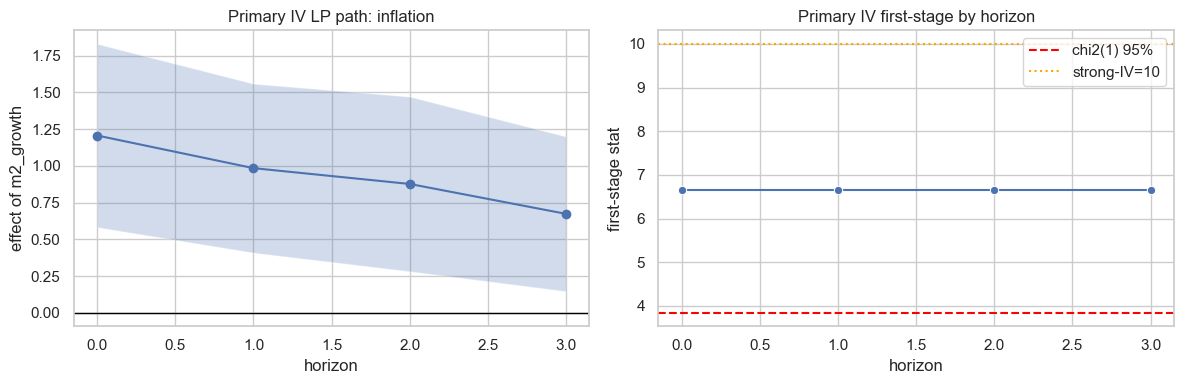

In [5]:
plot_data = primary[primary["outcome"] == "inflation"].sort_values("horizon")
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(plot_data["horizon"], plot_data["coef_m2_growth"], marker="o")
axes[0].fill_between(plot_data["horizon"], plot_data["ci_low_95"], plot_data["ci_high_95"], alpha=0.25)
axes[0].axhline(0, color="black", linewidth=1)
axes[0].set_title("Primary IV LP path: inflation")
axes[0].set_xlabel("horizon")
axes[0].set_ylabel("effect of m2_growth")

sns.lineplot(data=primary.groupby(["horizon"], as_index=False)["first_stage_stat"].mean(), x="horizon", y="first_stage_stat", marker="o", ax=axes[1])
axes[1].axhline(CHI2_1_95_CRITICAL, color="red", linestyle="--", label="chi2(1) 95%")
axes[1].axhline(STRONG_IV_STAT_THRESHOLD, color="orange", linestyle=":", label="strong-IV=10")
axes[1].set_title("Primary IV first-stage by horizon")
axes[1].set_ylabel("first-stage stat")
axes[1].legend()

fig.tight_layout()
fig.savefig(OUT_DIR / "phase2_inflation_lp_and_first_stage.png", dpi=170)
plt.show()

In [6]:
infl_primary = primary[primary["outcome"] == "inflation"].copy()
gdp_primary = primary[primary["outcome"] == "gdp_growth"].copy()

metrics = pd.DataFrame([
    {"metric": "inflation_sig_horizons_5pct_unadjusted", "value": int((infl_primary["p_value"] < 0.05).sum())},
    {"metric": "inflation_sig_horizons_5pct_holm", "value": int((infl_primary["p_value_holm"] < 0.05).sum())},
    {"metric": "gdp_sig_horizons_5pct", "value": int((gdp_primary["p_value"] < 0.05).sum())},
    {"metric": "inflation_min_first_stage_stat_primary", "value": float(infl_primary["first_stage_stat"].min())},
    {"metric": "inflation_relevance_gate_all_horizons", "value": bool((infl_primary["first_stage_stat"] > CHI2_1_95_CRITICAL).all())},
    {"metric": "inflation_strong_iv_all_horizons", "value": bool((infl_primary["first_stage_stat"] >= STRONG_IV_STAT_THRESHOLD).all())},
    {"metric": "fixed_sample_rows", "value": int(fixed_mask.sum())},
])

# IT stratified comparison (primary instrument only, same fixed sample and horizon lock)
strat_rows = []
for group in ["adopter", "never_adopter"]:
    subgroup_mask = fixed_mask & (lp_panel["it_group"] == group)
    for h in horizons["inflation"]:
        strat_rows.append(run_lp_iv(lp_panel, "inflation", h, "instrument_m2_external_level", fixed_mask=subgroup_mask) | {"it_group": group})

strat_table = pd.DataFrame(strat_rows).sort_values(["it_group", "horizon"])

lp_table.to_csv(OUT_DIR / "phase2_lp_iv_all_results.csv", index=False)
primary.to_csv(OUT_DIR / "phase2_lp_iv_primary_results.csv", index=False)
alt.to_csv(OUT_DIR / "phase2_lp_iv_alt_results.csv", index=False)
strat_table.to_csv(OUT_DIR / "phase2_lp_iv_it_stratified.csv", index=False)
metrics.to_csv(OUT_DIR / "phase2_interpretation_metrics.csv", index=False)

display(metrics)
display(strat_table)
print("Saved Phase 2 outputs to:", OUT_DIR)

,metric,value
0,inflation_sig_horizons_5pct_unadjusted,4
1,inflation_sig_horizons_5pct_holm,4
2,gdp_sig_horizons_5pct,0
3,inflation_min_first_stage_stat_primary,6.649581
4,inflation_relevance_gate_all_horizons,True
5,inflation_strong_iv_all_horizons,False
6,fixed_sample_rows,3293


,outcome,horizon,instrument,coef_m2_growth,std_error,p_value,ci_low_95,ci_high_95,nobs,first_stage_stat,first_stage_p,it_group
0,inflation,0,instrument_m2_external_level,0.744817,0.442373,0.092243,-0.122235,1.611868,656,1.257556,0.262114,adopter
1,inflation,1,instrument_m2_external_level,0.915848,0.531611,0.084929,-0.126110,1.957807,656,1.257556,0.262114,adopter
2,inflation,2,instrument_m2_external_level,0.720837,0.457670,0.115253,-0.176197,1.617870,656,1.257556,0.262114,adopter
3,inflation,3,instrument_m2_external_level,0.603729,0.507217,0.233937,-0.390416,1.597873,656,1.257556,0.262114,adopter
4,inflation,0,instrument_m2_external_level,1.419519,0.527112,0.007081,0.386379,2.452658,2637,3.359974,0.066799,never_adopter
5,inflation,1,instrument_m2_external_level,1.108709,0.459240,0.015769,0.208598,2.008819,2637,3.359974,0.066799,never_adopter
6,inflation,2,instrument_m2_external_level,1.030606,0.498382,0.038649,0.053776,2.007435,2637,3.359974,0.066799,never_adopter
7,inflation,3,instrument_m2_external_level,0.780543,0.417762,0.061708,-0.038271,1.599358,2637,3.359974,0.066799,never_adopter


Saved Phase 2 outputs to: /Users/stevenchung/Desktop/P12B_File/Monetary_Panel/03_analysis_notebooks/exports/phase2


## Interpretation for short-run Obj B

- Positive inflation LP-IV responses can coexist with weak-to-moderate first-stage strength.
- Keep claims at associational/limited-causal level unless strong-IV diagnostics improve.
- Use this notebook as the policy-dynamics layer after Phase 1 baseline.